# totalVI latent space visualization

This notebook loads the trained AnnData object generated in the previous step and uses the totalVI latent representation to compute neighbors, UMAP and Leiden clusters.

## 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load trained AnnData object

In [2]:
adata = sc.read_h5ad("../data/processed/malt_totalvi_trained.h5ad")

adata

AnnData object with n_obs × n_vars = 8412 × 33538
    obs: 'batch', '_scvi_labels', '_scvi_batch'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_totalVI', 'protein_expression'
    layers: 'counts'

## 3. Check totalVI latent representation

In [3]:
adata.obsm.keys()

KeysView(AxisArrays with keys: X_totalVI, protein_expression)

In [4]:
adata.obsm["X_totalVI"].shape

(8412, 20)

## 4. Compute neighbors using totalVI latent space

In [5]:
sc.pp.neighbors(
    adata,
    use_rep="X_totalVI",
    n_neighbors=15
)

## 5. Compute UMAP

In [6]:
sc.tl.umap(adata)

## 6. Leiden clustering

In [7]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    key_added="leiden_totalVI"
)

## 7. Visualize totalVI latent space

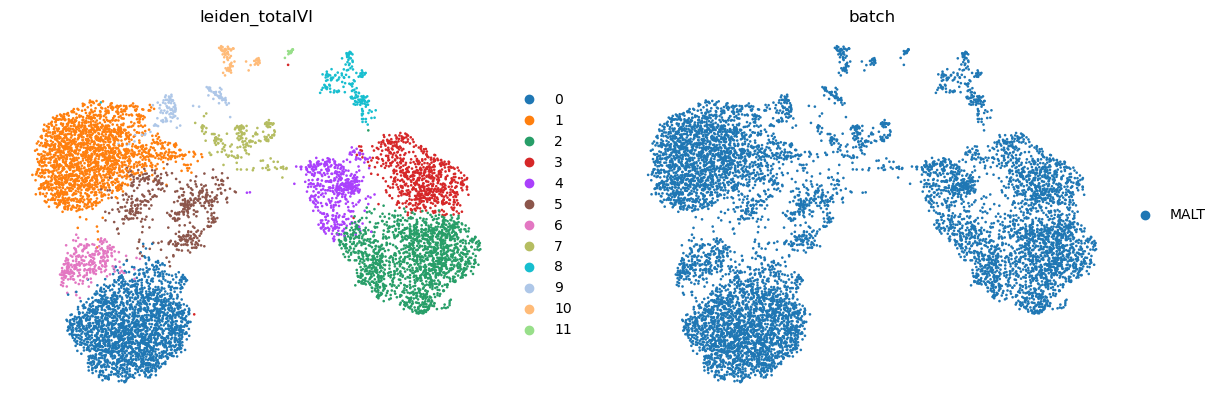

In [8]:
sc.pl.umap(
    adata,
    color=["leiden_totalVI", "batch"],
    frameon=False
)

In [9]:
import sys
print(sys.executable)

/home/dags/miniconda3/envs/totalvi_env/bin/python


In [10]:
import igraph
import leidenalg

print("igraph ok")
print("leidenalg ok")

igraph ok
leidenalg ok
